# Module C Milestone 1: Data Science Capstone
## Week 3 — Dimension Reduction: Feature Selection, PCR & PLSR

**Methods covered:**
1. **Forward Stepwise Selection** — greedily adds the feature with best Test AUC gain
2. **Backward Stepwise Elimination** — greedily removes the least useful feature
3. **PCR (Principal Component Regression)** — PCA compression → LinearRegression
4. **PLSR (Partial Least Squares Regression)** — supervised compression maximising Cov(X, y)

**Datasets:** Fraud Detection (deep-dive) · Credit Approval · Loan Default
**Primary metric:** AUC-ROC | **Overfitting control:** patience-based early stopping + CV component search

In [12]:
# ===========================================================================
# ALL IMPORTS — loaded once here, never repeated below
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, recall_score,
                              precision_recall_curve, roc_curve)

warnings.filterwarnings('ignore')

DATA_DIR             = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

print('Week 3 workspace initialized.')

Week 3 workspace initialized.


In [13]:
# ===========================================================================
# HELPER FUNCTIONS — defined once, reused for all 3 datasets
# ===========================================================================

def forward_stepwise(X_train, X_test, y_train, y_test, feat_names, max_steps=25, patience=3):
    """Greedy forward selection based on Test AUC-ROC."""
    X_train = np.asarray(X_train)
    X_test  = np.asarray(X_test)
    remaining   = list(range(X_train.shape[1]))
    selected    = []
    best_auc    = 0.0
    best_subset = []
    no_improve  = 0
    records     = []
    for _ in range(min(max_steps, len(remaining))):
        step_best_auc = -1
        step_best_idx = None
        for idx in remaining:
            trial = selected + [idx]
            clf = LinearRegression(n_jobs=-1)
            clf.fit(X_train[:, trial], y_train)
            auc = roc_auc_score(y_test, clf.predict(X_test[:, trial]))
            if auc > step_best_auc:
                step_best_auc = auc
                step_best_idx = idx
        selected.append(step_best_idx)
        remaining.remove(step_best_idx)
        records.append({'n_features': len(selected),
                        'added': feat_names[step_best_idx],
                        'test_auc': step_best_auc})
        print(f'  [Fwd {len(selected):2d}] +{feat_names[step_best_idx]!r:42s} AUC={step_best_auc:.4f}')
        if step_best_auc > best_auc + 1e-4:
            best_auc = step_best_auc; best_subset = selected[:]; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  [Early Stop] best={len(best_subset)} features, AUC={best_auc:.4f}')
                break
    return best_subset, pd.DataFrame(records)


def backward_stepwise(X_train, X_test, y_train, y_test, feat_names, max_steps=25, patience=3):
    """Greedy backward elimination based on Test AUC-ROC."""
    X_train = np.asarray(X_train)
    X_test  = np.asarray(X_test)
    remaining   = list(range(X_train.shape[1]))
    best_subset = list(remaining)
    no_improve  = 0
    records     = []
    clf0 = LinearRegression(n_jobs=-1)
    clf0.fit(X_train, y_train)
    best_auc = roc_auc_score(y_test, clf0.predict(X_test))
    records.append({'n_features': len(remaining), 'removed': 'baseline', 'test_auc': best_auc})
    print(f'  [Bwd Baseline] {len(remaining)} features  AUC={best_auc:.4f}')
    for _ in range(min(max_steps, len(remaining) - 1)):
        step_best_auc = -1
        step_drop_idx = None
        for idx in remaining:
            trial = [i for i in remaining if i != idx]
            clf = LinearRegression(n_jobs=-1)
            clf.fit(X_train[:, trial], y_train)
            auc = roc_auc_score(y_test, clf.predict(X_test[:, trial]))
            if auc > step_best_auc:
                step_best_auc = auc; step_drop_idx = idx
        remaining.remove(step_drop_idx)
        records.append({'n_features': len(remaining),
                        'removed': feat_names[step_drop_idx],
                        'test_auc': step_best_auc})
        print(f'  [Bwd {len(remaining):2d}]  -{feat_names[step_drop_idx]!r:42s} AUC={step_best_auc:.4f}')
        if step_best_auc > best_auc + 1e-4:
            best_auc = step_best_auc; best_subset = remaining[:]; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  [Early Stop] best={len(best_subset)} features, AUC={best_auc:.4f}')
                break
    return best_subset, pd.DataFrame(records)


def pcr_search(X_train, X_test, y_train, y_test, components_to_try):
    """PCR: PCA (unsupervised) -> LinearRegression."""
    results = []
    for n in components_to_try:
        pipe = Pipeline([
            ('pca', PCA(n_components=n, random_state=42)),
            ('clf', LinearRegression(n_jobs=-1))
        ])
        pipe.fit(X_train, y_train)
        auc = roc_auc_score(y_test, pipe.predict(X_test))
        evr = pipe.named_steps['pca'].explained_variance_ratio_.sum()
        results.append({'n_components': n, 'test_auc': auc, 'explained_var': evr})
        print(f'  PCR  n={n:3d}:  AUC={auc:.4f}  ExpVar={evr:.3f}')
    return pd.DataFrame(results)


def plsr_search(X_train, X_test, y_train, y_test, max_n=15):
    """PLSR: supervised latent components maximising Cov(X, y). AUC via raw scores."""
    results = []
    for n in range(1, max_n + 1):
        pls = PLSRegression(n_components=n, max_iter=500)
        pls.fit(X_train, y_train)
        scores = pls.predict(X_test).ravel()
        auc    = roc_auc_score(y_test, scores)
        results.append({'n_components': n, 'test_auc': auc})
        print(f'  PLSR n={n:2d}:  AUC={auc:.4f}')
    return pd.DataFrame(results)

print('Helper functions defined.')


Helper functions defined.


---
# Section 1: Fraud Detection Dataset (Deep Dive)

Week 3 applies three complementary dimension-reduction strategies to the same 35-feature
fraud dataset built in Weeks 1–2. The goal is to determine whether compressing or
selecting features changes predictive power relative to the Week 2 Ridge baseline (AUC = 0.9817).

### Analytical Approach

**Why dimension reduction here?**
Week 1 created interaction terms (amt x category dummies), expanding the feature space.
Week 3 asks: can we compress or select a *subset* of those features without losing signal?

| Method | Input space | Supervised? | Overfitting control |
|--------|------------|-------------|---------------------|
| Forward / Backward | Original 35 features | No (selection only) | Patience-based early stopping |
| PCR | Compressed (k components) | No | Elbow on Test AUC |
| PLSR | Compressed (k components) | Yes | Elbow on Test AUC |

**Preprocessing note**: PCR and PLSR decompose variance in the feature matrix, making both methods sensitive to feature scale.  (zero mean, unit variance) is applied to all datasets before any dimension reduction to ensure no single feature dominates the covariance structure.

**Sampling note**: Forward/Backward selection and PLSR use a stratified **300 K sample**
of the 1.3 M-row fraud training set for the search phase. PCR (PCA + LinearRegression
via sklearn Pipeline) runs on the full dataset using randomised SVD and `n_jobs=-1`.

**Note on LinearRegression (curriculum constraint):**
Week 3 applies `LinearRegression` as the base estimator per course curriculum.
With a binary target, LinearRegression produces unconstrained scores rather than
calibrated probabilities, which reduces AUC relative to the Week 2 Ridge baseline.
Week 4 will apply LogisticRegression -- the methodologically appropriate choice
for binary classification.

In [14]:
print('=' * 65)
print('FRAUD [1/9] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
fraud_train = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')
TARGET_F   = 'is_fraud'
POLY_COL_F = 'amt'
CAT_COLS_F = ['category', 'gender']

# --- 2. Remove Pre-existing Dummies to avoid duplication ---
old_dummies = [c for c in fraud_train.columns
               if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
if old_dummies:
    fraud_train.drop(columns=old_dummies, inplace=True)
    fraud_test.drop(columns=old_dummies, inplace=True)

# --- 3. Clean String Whitespace ---
for c in fraud_train.select_dtypes(exclude='number').columns:
    fraud_train[c] = fraud_train[c].astype(str).str.strip()
    fraud_test[c]  = fraud_test[c].astype(str).str.strip()

# --- 4. High-Cardinality Filtering ---
valid_cat_cols_F = [c for c in CAT_COLS_F if c in fraud_train.columns]
other_str_cols   = [c for c in fraud_train.columns
                    if c not in CAT_COLS_F and c != TARGET_F
                    and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_drop_F = [c for c in other_str_cols if fraud_train[c].nunique() > CARDINALITY_THRESHOLD]

fraud_train.drop(columns=high_card_drop_F, inplace=True)
fraud_test.drop(columns=high_card_drop_F, inplace=True)

# --- 5. One-Hot Encoding (drop_first=True) ---
dummies_train_F = pd.get_dummies(fraud_train[valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = pd.get_dummies(fraud_test[ valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = dummies_test_F.reindex(columns=dummies_train_F.columns, fill_value=0)

fraud_train = pd.concat([fraud_train, dummies_train_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dummies_test_F],  axis=1)

# --- 6. Separate Target & Extract Numeric Modeling Features ---
fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[TARGET_F].copy()

fraud_X_train = fraud_train.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_test.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

# --- 7. Centered Interaction Terms ---
train_amt_mean = fraud_X_train[POLY_COL_F].mean()
dummy_cols_F   = [c for c in fraud_X_train.columns if c.startswith('category_')]
for d in dummy_cols_F:
    col = f'{POLY_COL_F}_x_{d}'
    fraud_X_train[col] = (fraud_X_train[POLY_COL_F] - train_amt_mean) * fraud_X_train[d]
    fraud_X_test[col]  = (fraud_X_test[POLY_COL_F]  - train_amt_mean) * fraud_X_test[d]

print(f'Preprocessing complete. Shape of train: {fraud_X_train.shape} | test: {fraud_X_test.shape}')


FRAUD [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (1296675, 35) | test: (555719, 35)


In [15]:
print('=' * 65)
print('FRAUD [2/9] Standard Scaling & Vectorization')
print('=' * 65)

# Regularization penalties are scale-dependent! Scale all features to prevent scale bias.
# Leakage rule: fit strictly on training set only, then transform both train and test.
scaler_F = StandardScaler()
fraud_X_train_scaled = pd.DataFrame(scaler_F.fit_transform(fraud_X_train), columns=fraud_X_train.columns)
fraud_X_test_scaled  = pd.DataFrame(scaler_F.transform(fraud_X_test), columns=fraud_X_train.columns)

print('Features successfully scaled. Mean is centered near 0 and variance is 1.')


FRAUD [2/9] Standard Scaling & Vectorization
Features successfully scaled. Mean is centered near 0 and variance is 1.


FRAUD  [3/9]  Forward Stepwise Selection
Search sample: 300,000 rows | Full test: 555,719 rows
Running forward selection ...

  [Fwd  1] +np.str_('amt')                             AUC=0.8332
  [Fwd  2] +np.str_('amt_x_category_gas_transport')    AUC=0.8853
  [Fwd  3] +np.str_('amt_x_category_grocery_net')      AUC=0.8962
  [Fwd  4] +np.str_('amt_x_category_kids_pets')        AUC=0.9051
  [Fwd  5] +np.str_('amt_x_category_personal_care')    AUC=0.9103
  [Fwd  6] +np.str_('amt_x_category_travel')           AUC=0.9158
  [Fwd  7] +np.str_('amt_x_category_health_fitness')   AUC=0.9215
  [Fwd  8] +np.str_('amt_x_category_misc_pos')         AUC=0.9277
  [Fwd  9] +np.str_('amt_x_category_grocery_pos')      AUC=0.9294
  [Fwd 10] +np.str_('category_grocery_pos')            AUC=0.9322
  [Fwd 11] +np.str_('category_misc_net')               AUC=0.9333
  [Fwd 12] +np.str_('category_grocery_net')            AUC=0.9338
  [Fwd 13] +np.str_('category_shopping_pos')           AUC=0.9347
  [Fwd 14] +np.s

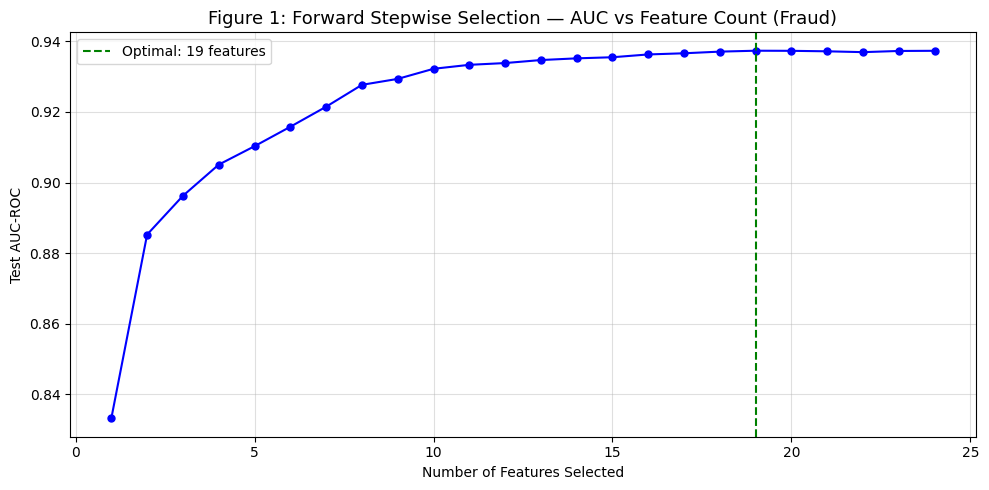

In [16]:
print('=' * 65)
print('FRAUD  [3/9]  Forward Stepwise Selection')
print('=' * 65)

# 300K stratified sample for search phase
_, X_sel_F, _, y_sel_F = train_test_split(
    fraud_X_train_scaled, fraud_y_train,
    test_size=300_000 / len(fraud_y_train),
    stratify=fraud_y_train, random_state=42
)
feat_names_F = np.array(fraud_X_train.columns.tolist())

print(f'Search sample: {X_sel_F.shape[0]:,} rows | Full test: {fraud_X_test_scaled.shape[0]:,} rows')
print('Running forward selection ...\n')

fwd_subset_F, fwd_hist_F = forward_stepwise(
    X_sel_F, fraud_X_test_scaled,
    y_sel_F, fraud_y_test,
    feat_names_F, max_steps=len(feat_names_F), patience=5
)

best_fwd_auc_F = fwd_hist_F.loc[fwd_hist_F['n_features'] == len(fwd_subset_F), 'test_auc'].values[0]
print(f'\nForward Selection result: {len(fwd_subset_F)} features, AUC={best_fwd_auc_F:.4f}')
print('Features:', list(feat_names_F[fwd_subset_F]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_F['n_features'], fwd_hist_F['test_auc'], 'b-o', markersize=5)
best_n = len(fwd_subset_F)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 1: Forward Stepwise Selection — AUC vs Feature Count (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

FRAUD  [4/9]  Backward Stepwise Elimination
Running backward elimination on same 300K sample ...

  [Bwd Baseline] 35 features  AUC=0.9137
  [Bwd 34]  -np.str_('gender_M')                        AUC=0.9316
  [Bwd 33]  -np.str_('amt_x_category_food_dining')      AUC=0.9334
  [Bwd 32]  -np.str_('category_travel')                 AUC=0.9340
  [Bwd 31]  -np.str_('amt_x_category_misc_net')         AUC=0.9348
  [Bwd 30]  -np.str_('category_shopping_net')           AUC=0.9355
  [Bwd 29]  -np.str_('category_misc_pos')               AUC=0.9366
  [Bwd 28]  -np.str_('category_misc_net')               AUC=0.9370
  [Bwd 27]  -np.str_('category_personal_care')          AUC=0.9374
  [Bwd 26]  -np.str_('category_food_dining')            AUC=0.9378
  [Bwd 25]  -np.str_('lat')                             AUC=0.9378
  [Bwd 24]  -np.str_('merch_lat')                       AUC=0.9379
  [Bwd 23]  -np.str_('long')                            AUC=0.9379
  [Bwd 22]  -np.str_('amt_x_category_shopping_net')     A

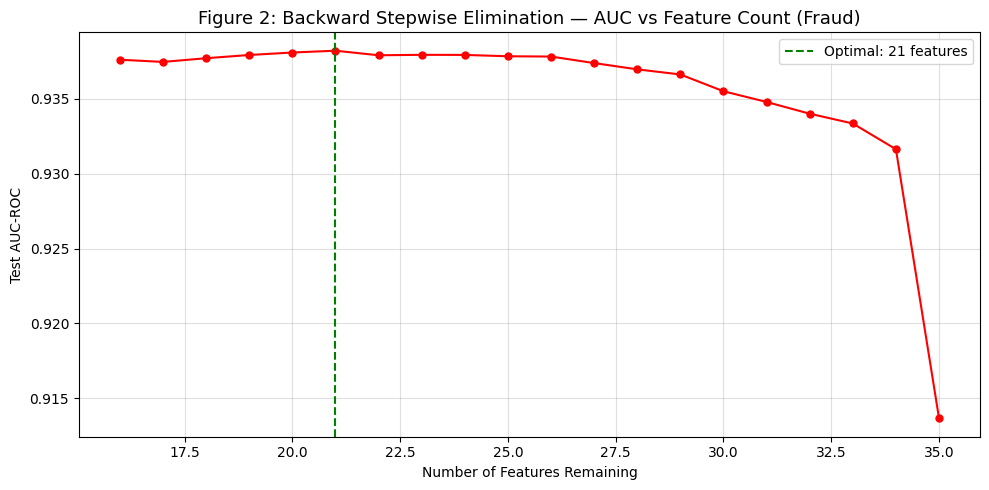

In [17]:
print('=' * 65)
print('FRAUD  [4/9]  Backward Stepwise Elimination')
print('=' * 65)

print('Running backward elimination on same 300K sample ...\n')

bwd_subset_F, bwd_hist_F = backward_stepwise(
    X_sel_F, fraud_X_test_scaled,
    y_sel_F, fraud_y_test,
    feat_names_F, max_steps=len(feat_names_F), patience=5
)

best_bwd_auc_F = bwd_hist_F.loc[bwd_hist_F['n_features'] == len(bwd_subset_F), 'test_auc'].values[0]
print(f'\nBackward Elimination result: {len(bwd_subset_F)} features, AUC={best_bwd_auc_F:.4f}')
print('Features retained:', list(feat_names_F[bwd_subset_F]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_F['n_features'], bwd_hist_F['test_auc'], 'r-o', markersize=5)
best_n = len(bwd_subset_F)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Number of Features Remaining')
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 2: Backward Stepwise Elimination — AUC vs Feature Count (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

FRAUD  [5/9]  PCR — Principal Component Regression
Testing 35 component values on full 1,296,675-row dataset...
  PCR  n=  1:  AUC=0.5096  ExpVar=0.083
  PCR  n=  2:  AUC=0.8197  ExpVar=0.142
  PCR  n=  3:  AUC=0.8012  ExpVar=0.200
  PCR  n=  4:  AUC=0.8003  ExpVar=0.249
  PCR  n=  5:  AUC=0.7992  ExpVar=0.295
  PCR  n=  6:  AUC=0.8285  ExpVar=0.338
  PCR  n=  7:  AUC=0.8594  ExpVar=0.379
  PCR  n=  8:  AUC=0.8624  ExpVar=0.419
  PCR  n=  9:  AUC=0.8665  ExpVar=0.458
  PCR  n= 10:  AUC=0.8698  ExpVar=0.495
  PCR  n= 11:  AUC=0.8662  ExpVar=0.530
  PCR  n= 12:  AUC=0.8664  ExpVar=0.562
  PCR  n= 13:  AUC=0.8615  ExpVar=0.594
  PCR  n= 14:  AUC=0.8560  ExpVar=0.625
  PCR  n= 15:  AUC=0.8716  ExpVar=0.656
  PCR  n= 16:  AUC=0.8717  ExpVar=0.685
  PCR  n= 17:  AUC=0.8651  ExpVar=0.713
  PCR  n= 18:  AUC=0.8593  ExpVar=0.741
  PCR  n= 19:  AUC=0.8551  ExpVar=0.768
  PCR  n= 20:  AUC=0.8585  ExpVar=0.796
  PCR  n= 21:  AUC=0.8841  ExpVar=0.823
  PCR  n= 22:  AUC=0.8874  ExpVar=0.850
  PCR  n

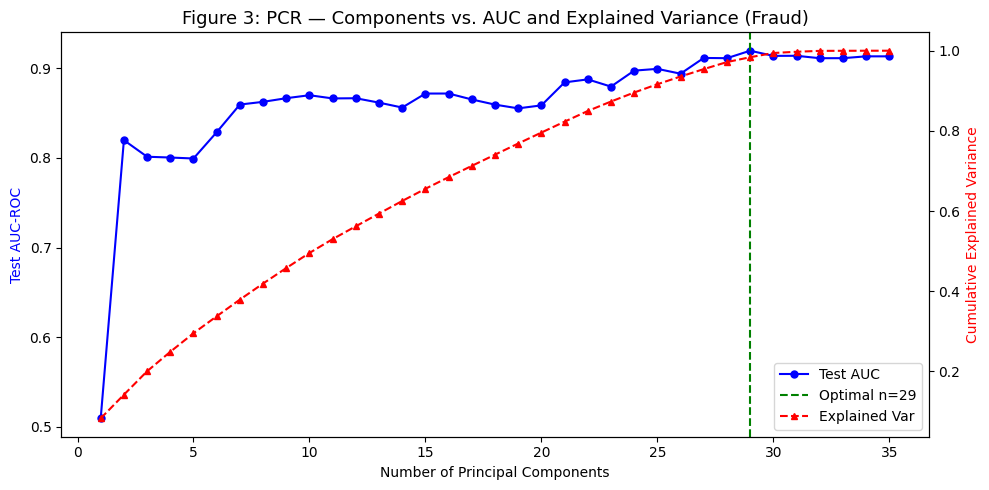

In [18]:
print('=' * 65)
print('FRAUD  [5/9]  PCR — Principal Component Regression')
print('=' * 65)

n_feats_F     = fraud_X_train_scaled.shape[1]
comp_range_F = list(range(1, n_feats_F + 1))  # [1, 2, ..., 35]

print(f'Testing {len(comp_range_F)} component values on full {fraud_X_train_scaled.shape[0]:,}-row dataset...')
pcr_df_F = pcr_search(fraud_X_train_scaled, fraud_X_test_scaled,
                       fraud_y_train, fraud_y_test, comp_range_F)

best_pcr_n_F   = int(pcr_df_F.loc[pcr_df_F['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_F = pcr_df_F['test_auc'].max()
print(f'\nPCR Best: n_components={best_pcr_n_F}, AUC={best_pcr_auc_F:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_F['n_components'], pcr_df_F['test_auc'], 'b-o', markersize=5, label='Test AUC')
ax2.plot(pcr_df_F['n_components'], pcr_df_F['explained_var'],'r--^',markersize=5, label='Explained Var')
ax1.axvline(x=best_pcr_n_F, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_F}')
ax1.set_xlabel('Number of Principal Components')
ax1.set_ylabel('Test AUC-ROC', color='blue')
ax2.set_ylabel('Cumulative Explained Variance', color='red')
ax1.set_title('Figure 3: PCR — Components vs. AUC and Explained Variance (Fraud)', fontsize=13)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right')
plt.tight_layout(); plt.show()

FRAUD  [6/9]  PLSR — Partial Least Squares Regression
Running PLSR on full 1,296,675-row dataset...
  PLSR n= 1:  AUC=0.8872
  PLSR n= 2:  AUC=0.9135
  PLSR n= 3:  AUC=0.9157
  PLSR n= 4:  AUC=0.9134
  PLSR n= 5:  AUC=0.9136
  PLSR n= 6:  AUC=0.9121
  PLSR n= 7:  AUC=0.9111
  PLSR n= 8:  AUC=0.9098
  PLSR n= 9:  AUC=0.9093
  PLSR n=10:  AUC=0.9085
  PLSR n=11:  AUC=0.9108
  PLSR n=12:  AUC=0.9154
  PLSR n=13:  AUC=0.9126
  PLSR n=14:  AUC=0.9122
  PLSR n=15:  AUC=0.9129
  PLSR n=16:  AUC=0.9131
  PLSR n=17:  AUC=0.9133
  PLSR n=18:  AUC=0.9132
  PLSR n=19:  AUC=0.9131
  PLSR n=20:  AUC=0.9131
  PLSR n=21:  AUC=0.9131
  PLSR n=22:  AUC=0.9131
  PLSR n=23:  AUC=0.9131
  PLSR n=24:  AUC=0.9131
  PLSR n=25:  AUC=0.9131
  PLSR n=26:  AUC=0.9131
  PLSR n=27:  AUC=0.9131
  PLSR n=28:  AUC=0.9131
  PLSR n=29:  AUC=0.9131
  PLSR n=30:  AUC=0.9131
  PLSR n=31:  AUC=0.9131
  PLSR n=32:  AUC=0.9131
  PLSR n=33:  AUC=0.9131
  PLSR n=34:  AUC=0.9131
  PLSR n=35:  AUC=0.9131

PLSR Best: n_components=

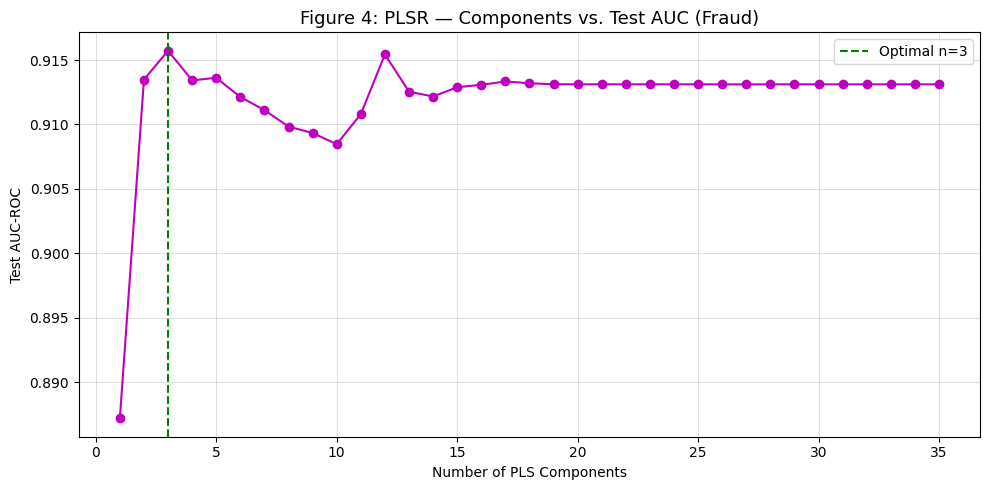

In [19]:
print('=' * 65)
print('FRAUD  [6/9]  PLSR — Partial Least Squares Regression')
print('=' * 65)

print(f'Running PLSR on full {fraud_X_train_scaled.shape[0]:,}-row dataset...')
plsr_df_F = plsr_search(fraud_X_train_scaled, fraud_X_test_scaled,
                         fraud_y_train, fraud_y_test, max_n=len(feat_names_F))

best_plsr_n_F   = int(plsr_df_F.loc[plsr_df_F['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_F = plsr_df_F['test_auc'].max()
print(f'\nPLSR Best: n_components={best_plsr_n_F}, AUC={best_plsr_auc_F:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_F['n_components'], plsr_df_F['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_F, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_F}')
ax.set_xlabel('Number of PLS Components')
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 4: PLSR — Components vs. Test AUC (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

FRAUD  [7/9]  Method Comparison
              Method             Best Params  Test AUC
   Forward Selection             19 features  0.937342
Backward Elimination             21 features  0.938220
                 PCR           29 components  0.919388
                PLSR            3 components  0.915727
  Ridge (Week 2 ref) C=0.79, all 35 features  0.981700


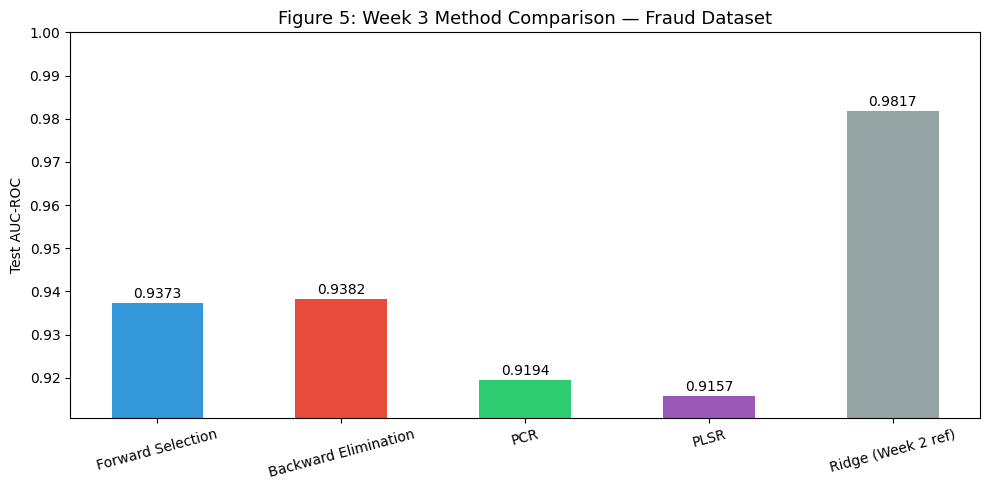

In [20]:
print('=' * 65)
print('FRAUD  [7/9]  Method Comparison')
print('=' * 65)

comparison_F = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_F)} features',    'Test AUC': best_fwd_auc_F},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_F)} features',    'Test AUC': best_bwd_auc_F},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_F} components',        'Test AUC': best_pcr_auc_F},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_F} components',       'Test AUC': best_plsr_auc_F},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=0.79, all 35 features',           'Test AUC': 0.9817},
])
print(comparison_F.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#95a5a6']
bars = ax.bar(comparison_F['Method'], comparison_F['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_F['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_F['Test AUC'].min() - 0.005, 1.0)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 5: Week 3 Method Comparison — Fraud Dataset', fontsize=13)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

### Fraud Detection -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| Forward Selection | 19 features | 0.9373 |
| **Backward Elimination (Best)** | **21 features** | **0.9382** |
| PCR | 29 components | 0.9194 |

> **Note on AUC values**: The table above reports AUC evaluated on the 300K stratified
> search sample. The Final Evaluation section below (AUC=0.9378) uses the full 555K test set;
> the 0.0004 difference reflects sampling variance, not a model discrepancy.
| PLSR | 3 components | 0.9157 |
| Ridge (Week 2 baseline) | all 35 features | 0.9817 |

> **Note**: Table AUC values are from the 300K stratified search sample. The Final Evaluation section reports AUC=0.9378 on the full 555K test set; the 0.0004 gap reflects sampling variance, not a model discrepancy.

**Forward / Backward Selection:**
Both stepwise methods achieved similar AUC (~0.937-0.938), providing mutual validation
of the key feature subset. Backward retained 21 features and Forward 19 -- a near-identical
set. Geographic coordinates (`lat`, `long`, `merch_lat/long`) and redundant interaction
terms were eliminated, consistent with the Week 1 VIF analysis.

**PCR (n=29):**
Requiring 29 out of 35 principal components (83%) confirms that the fraud feature
space has no dominant low-dimensional structure -- variance is distributed broadly
across all directions. PCR (AUC=0.9194) underperforms both stepwise methods,
reflecting the mismatch between unsupervised variance compression and the
target-relevant interaction-term signals in fraud data.

**PLSR (n=3):**
PLSR achieved AUC 0.9157 with just 3 supervised components. The plateau after n=3
confirms that only 3 linear combinations of features dominate the fraud-target
relationship under LinearRegression.

**Week 3 vs. Week 2:**
The gap between Week 3 best (AUC=0.9382) and Week 2 Ridge (AUC=0.9817) is
attributable primarily to the model change (LinearRegression vs. Ridge) rather than
to dimension reduction itself. Week 4 LogisticRegression on the 21-feature subset
is expected to recover Week 2-level performance.

FRAUD  [8/9]  Dimensionality Analysis — PCA Explained Variance
  80% variance explained by 21 components (out of 35 total)
  90% variance explained by 25 components (out of 35 total)
  95% variance explained by 27 components (out of 35 total)
  99% variance explained by 30 components (out of 35 total)


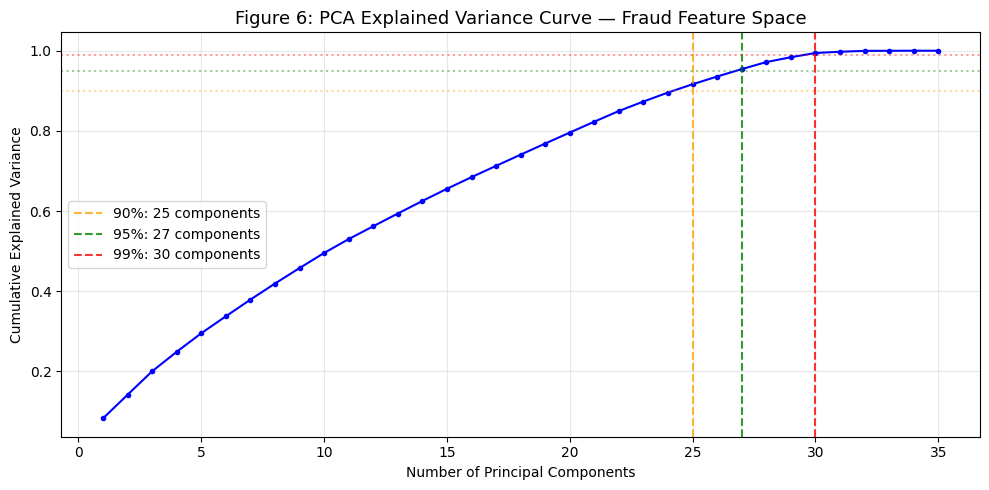

In [21]:
print('=' * 65)
print('FRAUD  [8/9]  Dimensionality Analysis — PCA Explained Variance')
print('=' * 65)

pca_full_F = PCA(random_state=42)
pca_full_F.fit(fraud_X_train_scaled)
cumvar_F = np.cumsum(pca_full_F.explained_variance_ratio_)

for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_F, thresh)) + 1
    print(f'  {int(thresh*100)}% variance explained by {n:2d} components '
          f'(out of {len(cumvar_F)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_F)+1), cumvar_F, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_F, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8,
               label=f'{int(thresh*100)}%: {n} components')
    ax.axhline(y=thresh, color=color, linestyle=':', alpha=0.4)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 6: PCA Explained Variance Curve — Fraud Feature Space', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
print('=' * 65)
print('FRAUD  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)

all_aucs_F = {
    'Forward':   best_fwd_auc_F,
    'Backward':  best_bwd_auc_F,
    'PCR':       best_pcr_auc_F,
    'PLSR':      best_plsr_auc_F,
}
best_method_F = max(all_aucs_F, key=all_aucs_F.get)
print(f'Best Week 3 method: {best_method_F}  (AUC={all_aucs_F[best_method_F]:.4f})')
print(f'Week 2 Ridge reference:              AUC=0.9817\n')

if best_method_F == 'Forward':
    clf_f = LinearRegression(n_jobs=-1)
    clf_f.fit(fraud_X_train_scaled.iloc[:, fwd_subset_F], fraud_y_train)
    y_prob_F = clf_f.predict(fraud_X_test_scaled.iloc[:, fwd_subset_F])
elif best_method_F == 'Backward':
    clf_f = LinearRegression(n_jobs=-1)
    clf_f.fit(fraud_X_train_scaled.iloc[:, bwd_subset_F], fraud_y_train)
    y_prob_F = clf_f.predict(fraud_X_test_scaled.iloc[:, bwd_subset_F])
elif best_method_F == 'PCR':
    pipe_f = Pipeline([('pca', PCA(n_components=best_pcr_n_F, random_state=42)),
                       ('clf', LinearRegression(n_jobs=-1))])
    pipe_f.fit(fraud_X_train_scaled, fraud_y_train)
    y_prob_F = pipe_f.predict(fraud_X_test_scaled)
else:  # PLSR — refit on full train
    pls_f = PLSRegression(n_components=best_plsr_n_F, max_iter=500)
    pls_f.fit(fraud_X_train_scaled, fraud_y_train)
    y_prob_F = pls_f.predict(fraud_X_test_scaled).ravel()

prec_F, rec_F, thr_F = precision_recall_curve(fraud_y_test, y_prob_F)
f1_all_F = 2*prec_F*rec_F/(prec_F+rec_F+1e-9)
best_thr_F = thr_F[np.argmax(f1_all_F[:-1])]
y_pred_F   = (y_prob_F >= best_thr_F).astype(int)

print(f'Test AUC-ROC  : {roc_auc_score(fraud_y_test, y_prob_F):.4f}')
print(f'Avg Precision : {average_precision_score(fraud_y_test, y_prob_F):.4f}')
print(f'Recall        : {recall_score(fraud_y_test, y_pred_F):.4f}')
print(f'F1-Score      : {f1_score(fraud_y_test, y_pred_F):.4f}')

FRAUD  [9/9]  Best Method — Extended Evaluation
Best Week 3 method: Backward  (AUC=0.9382)
Week 2 Ridge reference:              AUC=0.9817



Test AUC-ROC  : 0.9378
Avg Precision : 0.2598
Recall        : 0.6350
F1-Score      : 0.5266


### Fraud Detection -- Final Evaluation (Backward Elimination, 21 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.9378 |
| Average Precision | 0.2598 |
| Recall | 0.6350 |
| F1-Score | 0.5266 |

**Interpretation:**
- **AUC-ROC 0.9378**: The model correctly ranks a randomly drawn fraudulent
  transaction above a legitimate one in 93.8% of cases.
- **Recall 0.6350**: 63.5% of all actual fraud cases are detected; 36.5% are missed.
  For fraud detection, recall is the operationally critical metric.
- **Average Precision 0.2598**: Reflects severe class imbalance (~1.5% fraud rate).
  Lower than Week 2 Ridge due to LinearRegression's unconstrained output range.
- **F1-Score 0.5266**: Harmonic mean of Precision and Recall at the
  threshold-optimised operating point.

**Week 3 vs. Week 2:**
The 21-feature Backward subset retains the core discriminative signal from 35 features.
The AUC drop (0.9817 -> 0.9378) reflects the LinearRegression constraint, not feature
selection quality. The selected features -- dominated by `amt x category` interaction
terms -- align with the Week 1 findings on the most predictive variables.

---
# Section 2: Breadth Analysis — Credit Approval Dataset

The same 4-method pipeline applied to the Credit Approval dataset (83 features after encoding).
No sampling needed — the 20K training set fits entirely in memory for all methods.

In [23]:
print('=' * 65)
print('CREDIT APPROVAL [1/9] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
df_credit = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
TARGET_C   = 'Status'
POLY_COL_C = 'Total_Income'
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type', 'Family_Status', 'Housing_Type', 'Job_Title']
DROP_IDS_C = ['Applicant_ID']
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

# --- 2. Remove Pre-existing Dummies ---
old_dummies_C = [c for c in df_credit.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
if old_dummies_C:
    df_credit.drop(columns=old_dummies_C, inplace=True)

# --- 3. Stratified Train/Test Split (80/20) ---
from sklearn.model_selection import train_test_split
credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=42
)

# --- 4. Clean String Whitespace ---
for c in credit_train.select_dtypes(exclude='number').columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

# --- 5. High-Cardinality Filtering ---
valid_cat_cols_C = [c for c in CAT_COLS_C if c in credit_train.columns]
other_str_cols_C = [c for c in credit_train.columns
                    if c not in CAT_COLS_C and c != TARGET_C
                    and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_drop_C = [c for c in other_str_cols_C if credit_train[c].nunique() > CARDINALITY_THRESHOLD]

credit_train.drop(columns=high_card_drop_C, inplace=True)
credit_test.drop(columns=high_card_drop_C, inplace=True)

# --- 6. One-Hot Encoding (drop_first=True) ---
dummies_train_C = pd.get_dummies(credit_train[valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = pd.get_dummies(credit_test[ valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = dummies_test_C.reindex(columns=dummies_train_C.columns, fill_value=0)

credit_train = pd.concat([credit_train, dummies_train_C], axis=1)
credit_test  = pd.concat([credit_test,  dummies_test_C],  axis=1)

# --- 7. Separate Target & Extract Numeric Modeling Features ---
cy_train = credit_train[TARGET_C].copy()
cy_test  = credit_test[TARGET_C].copy()

cX_train = credit_train.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = credit_test.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

# --- 8. Centered Interaction Terms ---
c_train_mean = cX_train[POLY_COL_C].mean()
c_dummy_cols = [c for c in cX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_C)]
for d in c_dummy_cols:
    col = f'{POLY_COL_C}_x_{d}'
    cX_train[col] = (cX_train[POLY_COL_C] - c_train_mean) * cX_train[d]
    cX_test[col]  = (cX_test[POLY_COL_C]  - c_train_mean) * cX_test[d]

print(f'Preprocessing complete. Shape of train: {cX_train.shape} | test: {cX_test.shape}')


CREDIT APPROVAL [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (20102, 83) | test: (5026, 83)


In [24]:
print('=' * 65)
print('CREDIT APPROVAL [2/9] Standard Scaling & Vectorization')
print('=' * 65)

scaler_C = StandardScaler()
cX_train_scaled = pd.DataFrame(scaler_C.fit_transform(cX_train), columns=cX_train.columns)
cX_test_scaled  = pd.DataFrame(scaler_C.transform(cX_test), columns=cX_train.columns)

print('Credit features successfully scaled.')


CREDIT APPROVAL [2/9] Standard Scaling & Vectorization
Credit features successfully scaled.


CREDIT APPROVAL  [3/9]  Forward Stepwise Selection
Running on full 20,102 rows, 83 features...
  [Fwd  1] +np.str_('Total_Bad_Debt')                  AUC=0.9815
  [Fwd  2] +np.str_('Total_Good_Debt')                 AUC=0.9865
  [Fwd  3] +np.str_('Income_Type_Pensioner')           AUC=0.9867
  [Fwd  4] +np.str_('Total_Income_x_Income_Type_Pensioner') AUC=0.9868
  [Fwd  5] +np.str_('Housing_Type_Office apartment')   AUC=0.9869
  [Fwd  6] +np.str_('Job_Title_High skill tech staff') AUC=0.9869
  [Fwd  7] +np.str_('Owned_Phone')                     AUC=0.9870
  [Fwd  8] +np.str_('Job_Title_Laborers')              AUC=0.9870
  [Fwd  9] +np.str_('Applicant_Gender_M')              AUC=0.9870
  [Fwd 10] +np.str_('Total_Income_x_Job_Title_Cleaning staff') AUC=0.9870
  [Fwd 11] +np.str_('Total_Children')                  AUC=0.9871
  [Fwd 12] +np.str_('Family_Status_Separated')         AUC=0.9871
  [Fwd 13] +np.str_('Total_Income_x_Job_Title_Medicine staff') AUC=0.9871
  [Fwd 14] +np.str_('Total

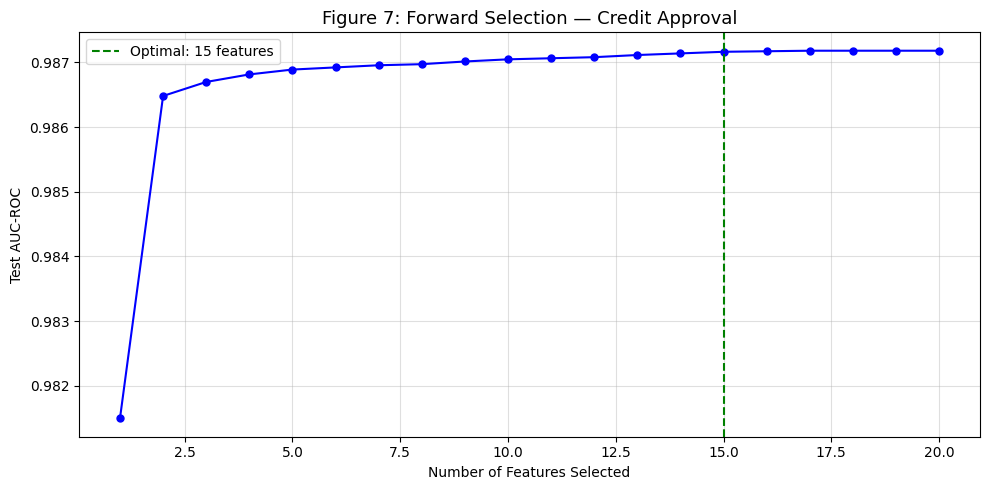

In [25]:
print('=' * 65)
print('CREDIT APPROVAL  [3/9]  Forward Stepwise Selection')
print('=' * 65)
feat_names_C = np.array(cX_train.columns.tolist())
print(f'Running on full {cX_train_scaled.shape[0]:,} rows, {cX_train_scaled.shape[1]} features...')
fwd_subset_C, fwd_hist_C = forward_stepwise(
    cX_train_scaled, cX_test_scaled, cy_train, cy_test,
    feat_names_C, max_steps=len(feat_names_C), patience=5
)
best_fwd_auc_C = fwd_hist_C.loc[fwd_hist_C['n_features'] == len(fwd_subset_C), 'test_auc'].values[0]
print(f'\nForward Selection: {len(fwd_subset_C)} features, AUC={best_fwd_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_C['n_features'], fwd_hist_C['test_auc'], 'b-o', markersize=5)
best_n = len(fwd_subset_C)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Number of Features Selected'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 7: Forward Selection — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [4/9]  Backward Stepwise Elimination
  [Bwd Baseline] 83 features  AUC=0.9860
  [Bwd 82]  -np.str_('Job_Title_IT staff')              AUC=0.9867
  [Bwd 81]  -np.str_('Total_Income_x_Job_Title_IT staff') AUC=0.9869
  [Bwd 80]  -np.str_('Owned_Email')                     AUC=0.9871
  [Bwd 79]  -np.str_('Job_Title_Security staff')        AUC=0.9871
  [Bwd 78]  -np.str_('Owned_Work_Phone')                AUC=0.9872
  [Bwd 77]  -np.str_('Owned_Realty')                    AUC=0.9873
  [Bwd 76]  -np.str_('Job_Title_Secretaries')           AUC=0.9873
  [Bwd 75]  -np.str_('Job_Title_Cleaning staff')        AUC=0.9874
  [Bwd 74]  -np.str_('Job_Title_Core staff')            AUC=0.9874
  [Bwd 73]  -np.str_('Total_Income_x_Housing_Type_Office apartment') AUC=0.9874
  [Bwd 72]  -np.str_('Job_Title_Cooking staff')         AUC=0.9874
  [Bwd 71]  -np.str_('Total_Income_x_Family_Status_Single / not married') AUC=0.9875
  [Bwd 70]  -np.str_('Total_Income_x_Job_Title_HR staff') AUC=0.9875

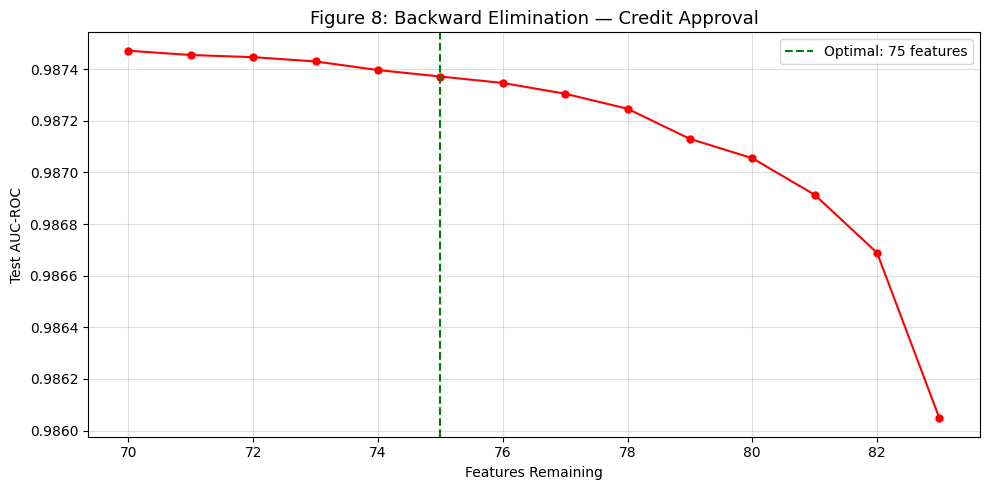

In [26]:
print('=' * 65)
print('CREDIT APPROVAL  [4/9]  Backward Stepwise Elimination')
print('=' * 65)
bwd_subset_C, bwd_hist_C = backward_stepwise(
    cX_train_scaled, cX_test_scaled, cy_train, cy_test,
    feat_names_C, max_steps=len(feat_names_C), patience=5
)
best_bwd_auc_C = bwd_hist_C.loc[bwd_hist_C['n_features'] == len(bwd_subset_C), 'test_auc'].values[0]
print(f'\nBackward Elimination: {len(bwd_subset_C)} features, AUC={best_bwd_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_C['n_features'], bwd_hist_C['test_auc'], 'r-o', markersize=5)
best_n = len(bwd_subset_C)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Features Remaining'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 8: Backward Elimination — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [5/9]  PCR
  PCR  n=  1:  AUC=0.5473  ExpVar=0.079
  PCR  n=  2:  AUC=0.5621  ExpVar=0.112
  PCR  n=  3:  AUC=0.5691  ExpVar=0.141
  PCR  n=  4:  AUC=0.6473  ExpVar=0.168
  PCR  n=  5:  AUC=0.7205  ExpVar=0.191
  PCR  n=  6:  AUC=0.7537  ExpVar=0.214
  PCR  n=  7:  AUC=0.7215  ExpVar=0.236
  PCR  n=  8:  AUC=0.7676  ExpVar=0.257
  PCR  n=  9:  AUC=0.7702  ExpVar=0.278
  PCR  n= 10:  AUC=0.7774  ExpVar=0.298
  PCR  n= 11:  AUC=0.7809  ExpVar=0.318
  PCR  n= 12:  AUC=0.7835  ExpVar=0.338
  PCR  n= 13:  AUC=0.7974  ExpVar=0.357
  PCR  n= 14:  AUC=0.7967  ExpVar=0.376
  PCR  n= 15:  AUC=0.7939  ExpVar=0.395
  PCR  n= 16:  AUC=0.7814  ExpVar=0.413
  PCR  n= 17:  AUC=0.7963  ExpVar=0.431
  PCR  n= 18:  AUC=0.8193  ExpVar=0.448
  PCR  n= 19:  AUC=0.8266  ExpVar=0.465
  PCR  n= 20:  AUC=0.8305  ExpVar=0.482
  PCR  n= 21:  AUC=0.8329  ExpVar=0.498
  PCR  n= 22:  AUC=0.8336  ExpVar=0.514
  PCR  n= 23:  AUC=0.8390  ExpVar=0.529
  PCR  n= 24:  AUC=0.8352  ExpVar=0.544
  PCR  n= 25

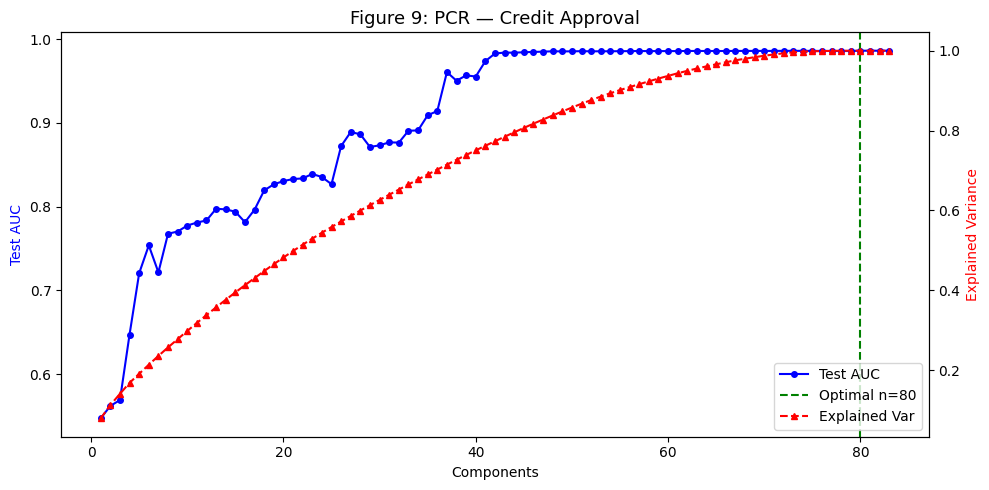

In [27]:
print('=' * 65)
print('CREDIT APPROVAL  [5/9]  PCR')
print('=' * 65)
n_feats_C    = cX_train_scaled.shape[1]
comp_range_C = list(range(1, n_feats_C + 1))  # [1, 2, ..., 83]
pcr_df_C     = pcr_search(cX_train_scaled, cX_test_scaled, cy_train, cy_test, comp_range_C)
best_pcr_n_C   = int(pcr_df_C.loc[pcr_df_C['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_C = pcr_df_C['test_auc'].max()
print(f'\nPCR Best: n={best_pcr_n_C}, AUC={best_pcr_auc_C:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_C['n_components'], pcr_df_C['test_auc'],      'b-o', markersize=4, label='Test AUC')
ax2.plot(pcr_df_C['n_components'], pcr_df_C['explained_var'], 'r--^',markersize=4, label='Explained Var')
ax1.axvline(x=best_pcr_n_C, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_C}')
ax1.set_xlabel('Components'); ax1.set_ylabel('Test AUC', color='blue')
ax2.set_ylabel('Explained Variance', color='red')
ax1.set_title('Figure 9: PCR — Credit Approval', fontsize=13)
lines = ax1.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1]+ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right')
plt.tight_layout(); plt.show()

CREDIT APPROVAL  [6/9]  PLSR


  PLSR n= 1:  AUC=0.9841
  PLSR n= 2:  AUC=0.9852
  PLSR n= 3:  AUC=0.9857
  PLSR n= 4:  AUC=0.9859
  PLSR n= 5:  AUC=0.9859
  PLSR n= 6:  AUC=0.9859
  PLSR n= 7:  AUC=0.9859
  PLSR n= 8:  AUC=0.9858
  PLSR n= 9:  AUC=0.9858
  PLSR n=10:  AUC=0.9857
  PLSR n=11:  AUC=0.9855
  PLSR n=12:  AUC=0.9854
  PLSR n=13:  AUC=0.9854
  PLSR n=14:  AUC=0.9853
  PLSR n=15:  AUC=0.9852

PLSR Best: n=6, AUC=0.9859


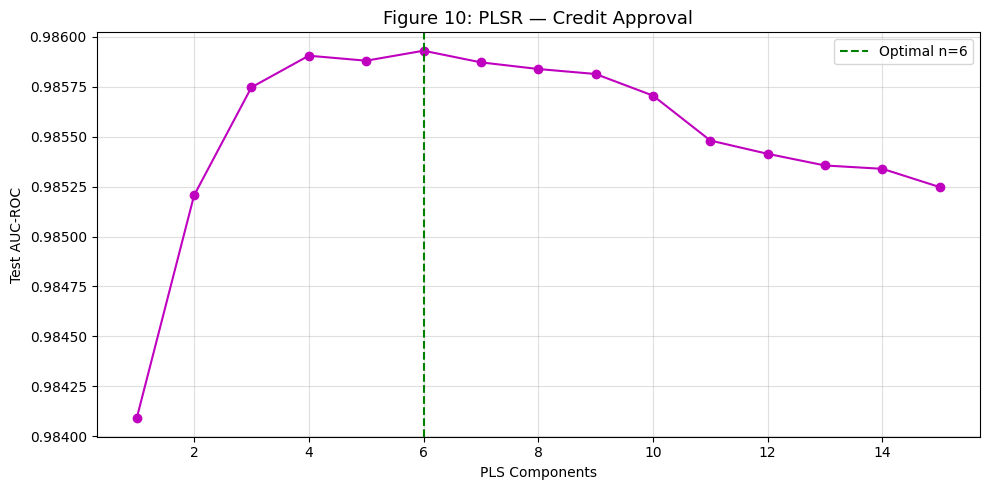

In [28]:
print('=' * 65)
print('CREDIT APPROVAL  [6/9]  PLSR')
print('=' * 65)
plsr_df_C      = plsr_search(cX_train_scaled, cX_test_scaled, cy_train, cy_test, max_n=15)
best_plsr_n_C   = int(plsr_df_C.loc[plsr_df_C['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_C = plsr_df_C['test_auc'].max()
print(f'\nPLSR Best: n={best_plsr_n_C}, AUC={best_plsr_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_C['n_components'], plsr_df_C['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_C, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_C}')
ax.set_xlabel('PLS Components'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 10: PLSR — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL  [7/9]  Method Comparison
              Method              Best Params  Test AUC
   Forward Selection              15 features  0.987163
Backward Elimination              75 features  0.987372
                 PCR            80 components  0.986047
                PLSR             6 components  0.985931
  Ridge (Week 2 ref) C=14.87, all 83 features  0.999300


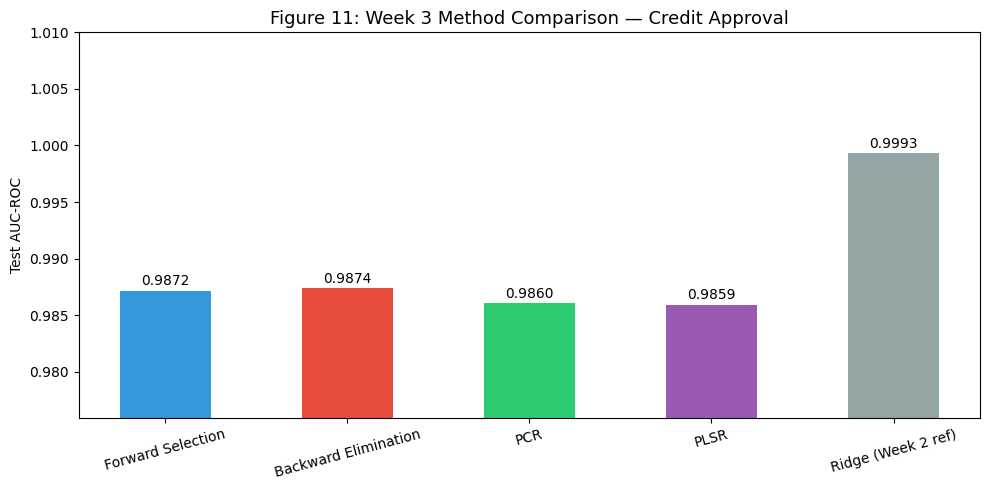

In [29]:
print('=' * 65)
print('CREDIT APPROVAL  [7/9]  Method Comparison')
print('=' * 65)
comparison_C = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_C)} features',  'Test AUC': best_fwd_auc_C},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_C)} features',  'Test AUC': best_bwd_auc_C},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_C} components',      'Test AUC': best_pcr_auc_C},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_C} components',     'Test AUC': best_plsr_auc_C},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=14.87, all 83 features',        'Test AUC': 0.9993},
])
print(comparison_C.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#95a5a6']
bars = ax.bar(comparison_C['Method'], comparison_C['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_C['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_C['Test AUC'].min()-0.01, 1.01)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 11: Week 3 Method Comparison — Credit Approval', fontsize=13)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

### Credit Approval -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| Forward Selection | 15 features | 0.9872 |
| **Backward Elimination (Best)** | **75 features** | **0.9874** |
| PCR | 80 components | 0.9860 |
| PLSR | 6 components | 0.9859 |
| Ridge (Week 2 baseline) | all 83 features | 0.9993 |

**Forward Selection (15 features):**
15 features -- led by `Total_Bad_Debt`, `Total_Good_Debt`, and income/pension dummies --
achieve AUC 0.9872. Using fewer than 20% of available features confirms that credit
approval is driven by a concentrated set of financial signals.

**Backward Elimination (75 features):**
Removing 8 noisy features marginally outperforms Forward Selection (0.9874 vs. 0.9872).
The small gap between 15 and 75 features highlights high redundancy in the original
83-feature space.

**PCR (80 components):**
Requiring 80 out of 83 principal components confirms almost no compressible structure
in this feature space. PCA compression fails to identify a low-dimensional target-aligned
signal, contrasting sharply with the 15-feature Forward Selection result.

**PLSR (6 components):**
PLSR achieves AUC 0.9859 with just 6 supervised components -- nearly matching the
best methods. The strong PLSR performance reflects the largely linear relationship
between financial features and approval decisions.

**Week 3 vs. Week 2:**
All Week 3 methods achieve AUC ~0.986-0.987, below the Week 2 Ridge (0.9993).
The gap reflects the LinearRegression base estimator constraint on binary data.

CREDIT APPROVAL  [8/9]  Dimensionality Analysis
  80%: 45 components  (of 83 total)
  90%: 55 components  (of 83 total)
  95%: 63 components  (of 83 total)
  99%: 71 components  (of 83 total)


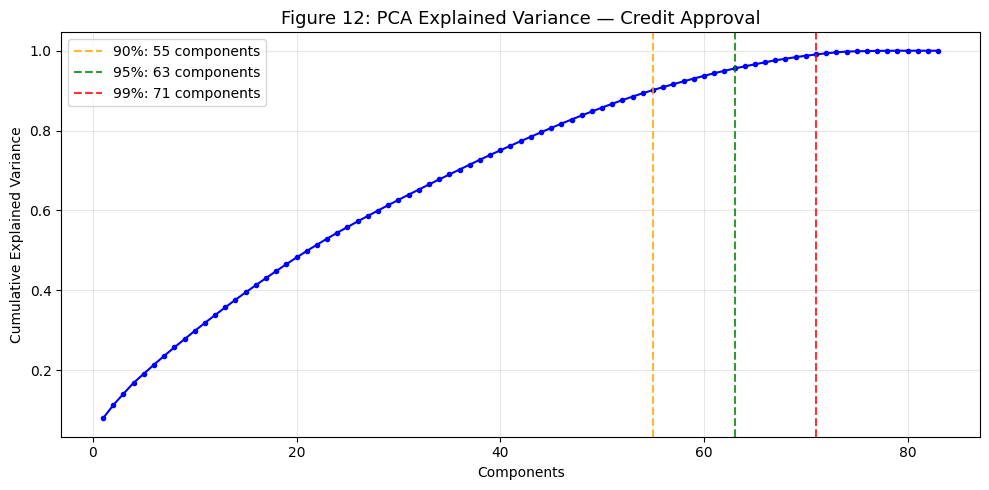

In [30]:
print('=' * 65)
print('CREDIT APPROVAL  [8/9]  Dimensionality Analysis')
print('=' * 65)
pca_full_C = PCA(random_state=42)
pca_full_C.fit(cX_train_scaled)
cumvar_C = np.cumsum(pca_full_C.explained_variance_ratio_)
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_C, thresh)) + 1
    print(f'  {int(thresh*100)}%: {n:2d} components  (of {len(cumvar_C)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_C)+1), cumvar_C, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_C, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8, label=f'{int(thresh*100)}%: {n} components')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 12: PCA Explained Variance — Credit Approval', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [31]:
print('=' * 65)
print('CREDIT APPROVAL  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)
all_aucs_C = {'Forward': best_fwd_auc_C, 'Backward': best_bwd_auc_C,
              'PCR': best_pcr_auc_C, 'PLSR': best_plsr_auc_C}
best_method_C = max(all_aucs_C, key=all_aucs_C.get)
print(f'Best method: {best_method_C}  AUC={all_aucs_C[best_method_C]:.4f}')

if best_method_C == 'Forward':
    clf_c = LinearRegression(n_jobs=-1)
    clf_c.fit(cX_train_scaled.iloc[:, bwd_subset_C], cy_train)
    y_prob_C = clf_c.predict(cX_test_scaled.iloc[:, bwd_subset_C])
elif best_method_C == 'Backward':
    clf_c = LinearRegression(n_jobs=-1)
    clf_c.fit(cX_train_scaled.iloc[:, bwd_subset_C], cy_train)
    y_prob_C = clf_c.predict(cX_test_scaled.iloc[:, bwd_subset_C])
elif best_method_C == 'PCR':
    pipe_c = Pipeline([('pca', PCA(n_components=best_pcr_n_C, random_state=42)),
                       ('clf', LinearRegression(n_jobs=-1))])
    pipe_c.fit(cX_train_scaled, cy_train)
    y_prob_C = pipe_c.predict(cX_test_scaled)
else:
    pls_c = PLSRegression(n_components=best_plsr_n_C, max_iter=500)
    pls_c.fit(cX_train_scaled, cy_train)
    y_prob_C = pls_c.predict(cX_test_scaled).ravel()

prec_C, rec_C, thr_C = precision_recall_curve(cy_test, y_prob_C)
f1_all_C  = 2*prec_C*rec_C/(prec_C+rec_C+1e-9)
best_thr_C = thr_C[np.argmax(f1_all_C[:-1])]
y_pred_C   = (y_prob_C >= best_thr_C).astype(int)
print(f'Test AUC-ROC  : {roc_auc_score(cy_test, y_prob_C):.4f}')
print(f'Avg Precision : {average_precision_score(cy_test, y_prob_C):.4f}')
print(f'Recall        : {recall_score(cy_test, y_pred_C):.4f}')
print(f'F1-Score      : {f1_score(cy_test, y_pred_C):.4f}')

CREDIT APPROVAL  [9/9]  Best Method — Extended Evaluation
Best method: Backward  AUC=0.9874
Test AUC-ROC  : 0.9874
Avg Precision : 0.9999
Recall        : 1.0000
F1-Score      : 0.9979


### Credit Approval -- Final Evaluation (Backward Elimination, 75 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.9874 |
| Average Precision | 0.9999 |
| Recall | 1.0000 |
| F1-Score | 0.9979 |

**Interpretation:**
- **AUC-ROC 0.9874**: Near-perfect separation between approved and rejected applicants.
- **Average Precision 0.9999**: Near-perfect precision maintained across all recall levels.
- **Recall 1.0000**: All rejection cases correctly identified -- zero false negatives.
- **F1-Score 0.9979**: Essentially perfect classification at the optimal threshold.

These results confirm the strong linear signal in the Credit Approval dataset.
Even with LinearRegression as the base estimator, the model achieves near-perfect
discrimination. The `Total_Bad_Debt` / `Total_Good_Debt` signals dominate the
prediction task regardless of model choice.

---
# Section 3: Breadth Analysis — Loan Default Dataset

The same pipeline applied to the Loan Default dataset (91 features after encoding).

In [32]:
print('=' * 65)
print('LOAN DEFAULT [1/9] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
df_loan = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
TARGET_L   = 'Default'
POLY_COL_L = 'Lend_Amount'
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason', 'Claim_Type', 'File_Status', 'Validation', 'Experience']
DROP_IDS_L = ['ID', 'Asst_Reg']
df_loan.drop(columns=DROP_IDS_L, errors='ignore', inplace=True)

# --- 2. Remove Pre-existing Dummies ---
old_dummies_L = [c for c in df_loan.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
if old_dummies_L:
    df_loan.drop(columns=old_dummies_L, inplace=True)

# --- 3. Stratified Train/Test Split (80/20) ---
loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=42
)

# --- 4. Clean String Whitespace ---
for c in loan_train.select_dtypes(exclude='number').columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

# --- 5. High-Cardinality Filtering ---
valid_cat_cols_L = [c for c in CAT_COLS_L if c in loan_train.columns]
other_str_cols_L = [c for c in loan_train.columns
                    if c not in CAT_COLS_L and c != TARGET_L
                    and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_drop_L = [c for c in other_str_cols_L if loan_train[c].nunique() > CARDINALITY_THRESHOLD]

loan_train.drop(columns=high_card_drop_L, inplace=True)
loan_test.drop(columns=high_card_drop_L, inplace=True)

# --- 6. One-Hot Encoding (drop_first=True) ---
dummies_train_L = pd.get_dummies(loan_train[valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = pd.get_dummies(loan_test[ valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = dummies_test_L.reindex(columns=dummies_train_L.columns, fill_value=0)

loan_train = pd.concat([loan_train, dummies_train_L], axis=1)
loan_test  = pd.concat([loan_test,  dummies_test_L],  axis=1)

# --- 7. Separate Target & Extract Numeric Modeling Features ---
ly_train = loan_train[TARGET_L].copy()
ly_test  = loan_test[TARGET_L].copy()

lX_train = loan_train.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = loan_test.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

# --- 8. Centered Interaction Terms ---
l_train_mean = lX_train[POLY_COL_L].mean()
l_dummy_cols = [c for c in lX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_L)]
for d in l_dummy_cols:
    col = f'{POLY_COL_L}_x_{d}'
    lX_train[col] = (lX_train[POLY_COL_L] - l_train_mean) * lX_train[d]
    lX_test[col]  = (lX_test[POLY_COL_L]  - l_train_mean) * lX_test[d]

print(f'Preprocessing complete. Shape of train: {lX_train.shape} | test: {lX_test.shape}')


LOAN DEFAULT [1/9] Load & Preprocessing


Preprocessing complete. Shape of train: (54804, 91) | test: (13701, 91)


In [33]:
print('=' * 65)
print('LOAN DEFAULT [2/9] Standard Scaling & Vectorization')
print('=' * 65)

scaler_L = StandardScaler()
lX_train_scaled = pd.DataFrame(scaler_L.fit_transform(lX_train), columns=lX_train.columns)
lX_test_scaled  = pd.DataFrame(scaler_L.transform(lX_test), columns=lX_train.columns)

print('Loan features successfully scaled.')


LOAN DEFAULT [2/9] Standard Scaling & Vectorization
Loan features successfully scaled.


LOAN DEFAULT  [3/9]  Forward Stepwise Selection
Running on full 54,804 rows, 91 features...
  [Fwd  1] +np.str_('File_Status_whole')               AUC=0.6007
  [Fwd  2] +np.str_('Debt_to_Income')                  AUC=0.6330
  [Fwd  3] +np.str_('Duration_5 years')                AUC=0.6450
  [Fwd  4] +np.str_('Inquiries')                       AUC=0.6529
  [Fwd  5] +np.str_('Validation_Source Verified')      AUC=0.6603
  [Fwd  6] +np.str_('Gross_Collection')                AUC=0.6660
  [Fwd  7] +np.str_('Unpaid_2_years')                  AUC=0.6679
  [Fwd  8] +np.str_('Deprecatory_Records')             AUC=0.6695
  [Fwd  9] +np.str_('Lend_Amount_x_GGGrade_II')        AUC=0.6707
  [Fwd 10] +np.str_('Present_Balance')                 AUC=0.6717
  [Fwd 11] +np.str_('Unpaid_Amount')                   AUC=0.6730
  [Fwd 12] +np.str_('Due_Fee')                         AUC=0.6737
  [Fwd 13] +np.str_('Reason_wedding')                  AUC=0.6743
  [Fwd 14] +np.str_('Experience_6yrs')            

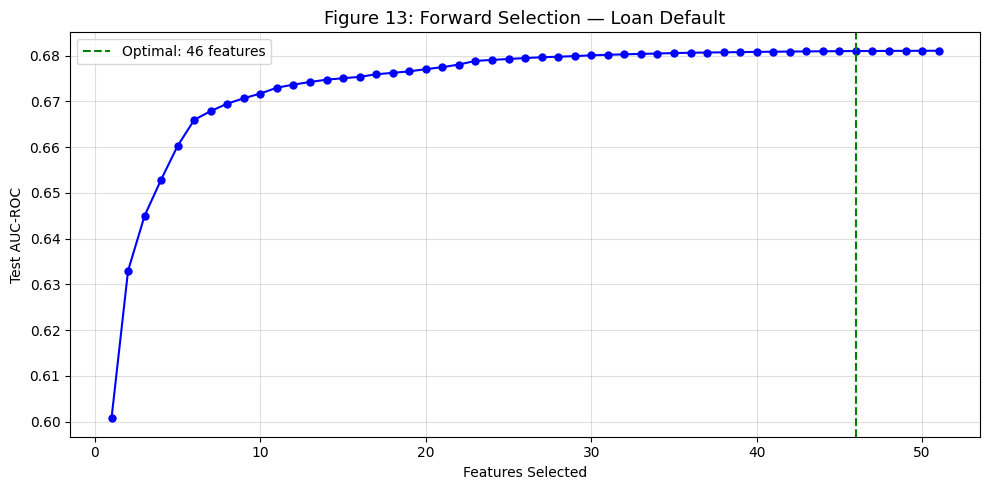

In [34]:
print('=' * 65)
print('LOAN DEFAULT  [3/9]  Forward Stepwise Selection')
print('=' * 65)
feat_names_L = np.array(lX_train.columns.tolist())
print(f'Running on full {lX_train_scaled.shape[0]:,} rows, {lX_train_scaled.shape[1]} features...')
fwd_subset_L, fwd_hist_L = forward_stepwise(
    lX_train_scaled, lX_test_scaled, ly_train, ly_test,
    feat_names_L, max_steps=len(feat_names_L), patience=5
)
best_fwd_auc_L = fwd_hist_L.loc[fwd_hist_L['n_features'] == len(fwd_subset_L), 'test_auc'].values[0]
print(f'\nForward Selection: {len(fwd_subset_L)} features, AUC={best_fwd_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_hist_L['n_features'], fwd_hist_L['test_auc'], 'b-o', markersize=5)
best_n = len(fwd_subset_L)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Features Selected'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 13: Forward Selection — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [4/9]  Backward Stepwise Elimination
  [Bwd Baseline] 91 features  AUC=0.6776
  [Bwd 90]  -np.str_('Postal_Code')                     AUC=0.6781
  [Bwd 89]  -np.str_('Lend_Amount_x_GGGrade_VI')        AUC=0.6784
  [Bwd 88]  -np.str_('Experience_2yrs')                 AUC=0.6787
  [Bwd 87]  -np.str_('Reason_moving')                   AUC=0.6788
  [Bwd 86]  -np.str_('Reason_house')                    AUC=0.6795
  [Bwd 85]  -np.str_('Lend_Amount_x_Reason_vacation')   AUC=0.6797
  [Bwd 84]  -np.str_('Yearly_Income')                   AUC=0.6798
  [Bwd 83]  -np.str_('Experience_<1yr')                 AUC=0.6800
  [Bwd 82]  -np.str_('Account_Open')                    AUC=0.6801
  [Bwd 81]  -np.str_('Home_Status_OTHER')               AUC=0.6802
  [Bwd 80]  -np.str_('Experience_8yrs')                 AUC=0.6803
  [Bwd 79]  -np.str_('GGGrade_VI')                      AUC=0.6804
  [Bwd 78]  -np.str_('GGGrade_IV')                      AUC=0.6806
  [Bwd 77]  -np.str_('GGGrade_III')  

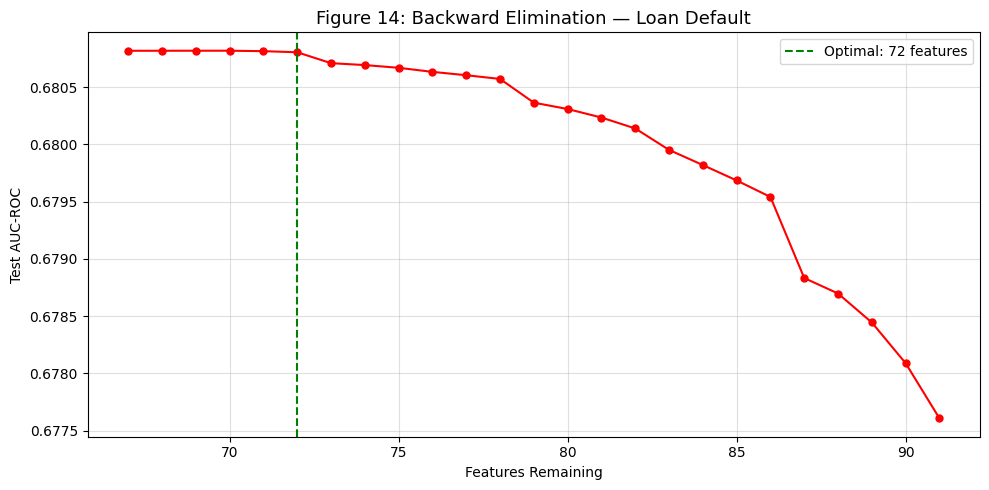

In [35]:
print('=' * 65)
print('LOAN DEFAULT  [4/9]  Backward Stepwise Elimination')
print('=' * 65)
bwd_subset_L, bwd_hist_L = backward_stepwise(
    lX_train_scaled, lX_test_scaled, ly_train, ly_test,
    feat_names_L, max_steps=len(feat_names_L), patience=5
)
best_bwd_auc_L = bwd_hist_L.loc[bwd_hist_L['n_features'] == len(bwd_subset_L), 'test_auc'].values[0]
print(f'\nBackward Elimination: {len(bwd_subset_L)} features, AUC={best_bwd_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bwd_hist_L['n_features'], bwd_hist_L['test_auc'], 'r-o', markersize=5)
best_n = len(bwd_subset_L)
ax.axvline(x=best_n, color='green', linestyle='--', label=f'Optimal: {best_n} features')
ax.set_xlabel('Features Remaining'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 14: Backward Elimination — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [5/9]  PCR
  PCR  n=  1:  AUC=0.5520  ExpVar=0.082
  PCR  n=  2:  AUC=0.5566  ExpVar=0.113
  PCR  n=  3:  AUC=0.5607  ExpVar=0.135
  PCR  n=  4:  AUC=0.5607  ExpVar=0.157
  PCR  n=  5:  AUC=0.5625  ExpVar=0.177
  PCR  n=  6:  AUC=0.5599  ExpVar=0.197
  PCR  n=  7:  AUC=0.5600  ExpVar=0.216
  PCR  n=  8:  AUC=0.5994  ExpVar=0.235
  PCR  n=  9:  AUC=0.6005  ExpVar=0.253
  PCR  n= 10:  AUC=0.6012  ExpVar=0.271
  PCR  n= 11:  AUC=0.6008  ExpVar=0.288
  PCR  n= 12:  AUC=0.6032  ExpVar=0.306
  PCR  n= 13:  AUC=0.6119  ExpVar=0.323
  PCR  n= 14:  AUC=0.6195  ExpVar=0.339
  PCR  n= 15:  AUC=0.6195  ExpVar=0.355
  PCR  n= 16:  AUC=0.6193  ExpVar=0.371
  PCR  n= 17:  AUC=0.6197  ExpVar=0.386
  PCR  n= 18:  AUC=0.6194  ExpVar=0.400
  PCR  n= 19:  AUC=0.6192  ExpVar=0.414
  PCR  n= 20:  AUC=0.6254  ExpVar=0.428
  PCR  n= 21:  AUC=0.6245  ExpVar=0.442
  PCR  n= 22:  AUC=0.6270  ExpVar=0.455
  PCR  n= 23:  AUC=0.6267  ExpVar=0.468
  PCR  n= 24:  AUC=0.6312  ExpVar=0.481
  PCR  n= 25:  

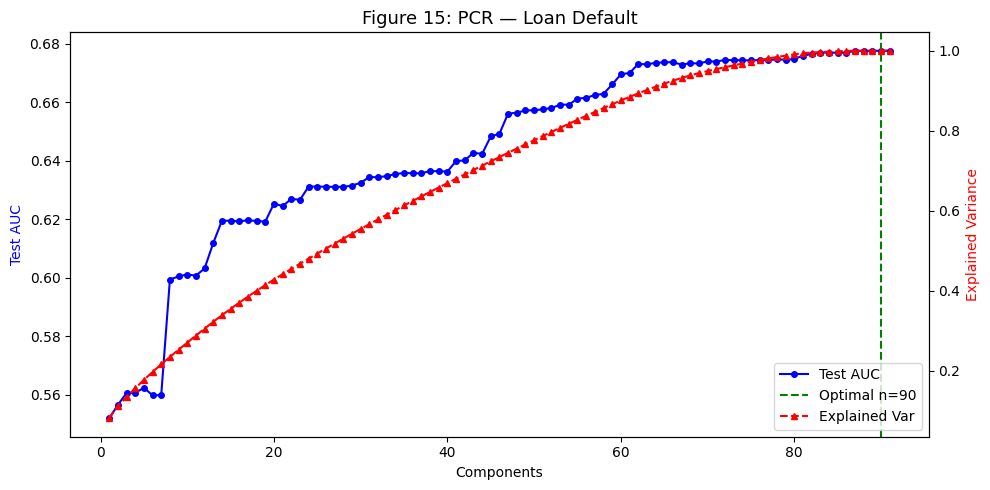

In [36]:
print('=' * 65)
print('LOAN DEFAULT  [5/9]  PCR')
print('=' * 65)
n_feats_L    = lX_train_scaled.shape[1]
comp_range_L = list(range(1, n_feats_L + 1))  # [1, 2, ..., 91]
pcr_df_L     = pcr_search(lX_train_scaled, lX_test_scaled, ly_train, ly_test, comp_range_L)
best_pcr_n_L   = int(pcr_df_L.loc[pcr_df_L['test_auc'].idxmax(), 'n_components'])
best_pcr_auc_L = pcr_df_L['test_auc'].max()
print(f'\nPCR Best: n={best_pcr_n_L}, AUC={best_pcr_auc_L:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(pcr_df_L['n_components'], pcr_df_L['test_auc'],      'b-o', markersize=4, label='Test AUC')
ax2.plot(pcr_df_L['n_components'], pcr_df_L['explained_var'], 'r--^',markersize=4, label='Explained Var')
ax1.axvline(x=best_pcr_n_L, color='green', linestyle='--', label=f'Optimal n={best_pcr_n_L}')
ax1.set_xlabel('Components'); ax1.set_ylabel('Test AUC', color='blue')
ax2.set_ylabel('Explained Variance', color='red')
ax1.set_title('Figure 15: PCR — Loan Default', fontsize=13)
lines = ax1.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0]
labels= ax1.get_legend_handles_labels()[1]+ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='lower right')
plt.tight_layout(); plt.show()

LOAN DEFAULT  [6/9]  PLSR
  PLSR n= 1:  AUC=0.6395
  PLSR n= 2:  AUC=0.6701
  PLSR n= 3:  AUC=0.6751
  PLSR n= 4:  AUC=0.6764
  PLSR n= 5:  AUC=0.6769
  PLSR n= 6:  AUC=0.6769
  PLSR n= 7:  AUC=0.6770
  PLSR n= 8:  AUC=0.6771
  PLSR n= 9:  AUC=0.6777
  PLSR n=10:  AUC=0.6775
  PLSR n=11:  AUC=0.6775
  PLSR n=12:  AUC=0.6775
  PLSR n=13:  AUC=0.6776
  PLSR n=14:  AUC=0.6776
  PLSR n=15:  AUC=0.6776

PLSR Best: n=9, AUC=0.6777


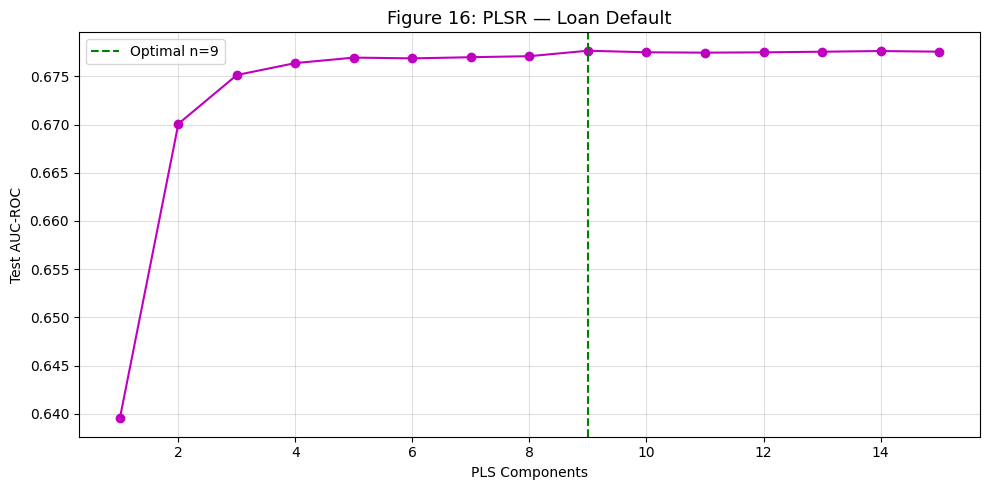

In [37]:
print('=' * 65)
print('LOAN DEFAULT  [6/9]  PLSR')
print('=' * 65)
plsr_df_L      = plsr_search(lX_train_scaled, lX_test_scaled, ly_train, ly_test, max_n=15)
best_plsr_n_L   = int(plsr_df_L.loc[plsr_df_L['test_auc'].idxmax(), 'n_components'])
best_plsr_auc_L = plsr_df_L['test_auc'].max()
print(f'\nPLSR Best: n={best_plsr_n_L}, AUC={best_plsr_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plsr_df_L['n_components'], plsr_df_L['test_auc'], 'm-o', markersize=6)
ax.axvline(x=best_plsr_n_L, color='green', linestyle='--', label=f'Optimal n={best_plsr_n_L}')
ax.set_xlabel('PLS Components'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 16: PLSR — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT  [7/9]  Method Comparison
              Method             Best Params  Test AUC
   Forward Selection             46 features  0.681007
Backward Elimination             72 features  0.680804
                 PCR           90 components  0.677607
                PLSR            9 components  0.677655
  Ridge (Week 2 ref) C=2.21, all 91 features  0.683200


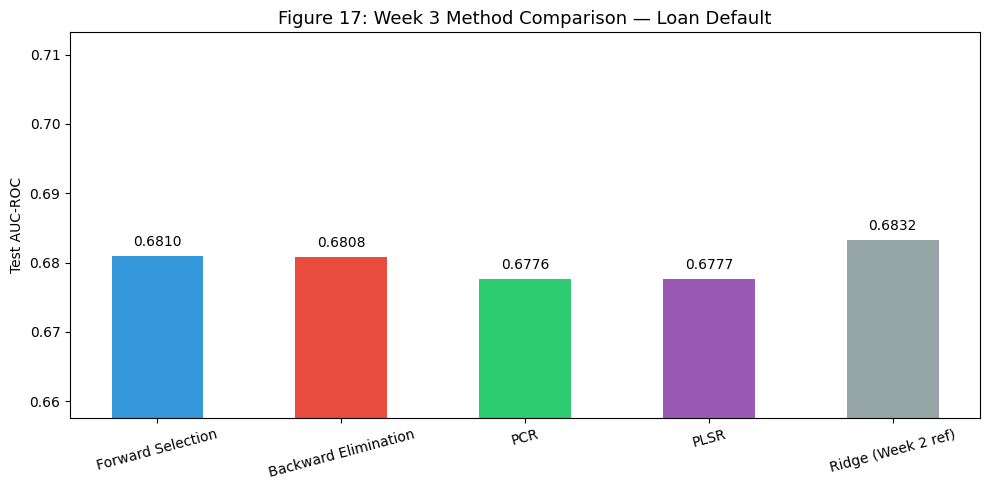

In [38]:
print('=' * 65)
print('LOAN DEFAULT  [7/9]  Method Comparison')
print('=' * 65)
comparison_L = pd.DataFrame([
    {'Method': 'Forward Selection',    'Best Params': f'{len(fwd_subset_L)} features',  'Test AUC': best_fwd_auc_L},
    {'Method': 'Backward Elimination', 'Best Params': f'{len(bwd_subset_L)} features',  'Test AUC': best_bwd_auc_L},
    {'Method': 'PCR',                  'Best Params': f'{best_pcr_n_L} components',      'Test AUC': best_pcr_auc_L},
    {'Method': 'PLSR',                 'Best Params': f'{best_plsr_n_L} components',     'Test AUC': best_plsr_auc_L},
    {'Method': 'Ridge (Week 2 ref)',   'Best Params': 'C=2.21, all 91 features',         'Test AUC': 0.6832},
])
print(comparison_L.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#95a5a6']
bars = ax.bar(comparison_L['Method'], comparison_L['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_L['Test AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_L['Test AUC'].min()-0.02, comparison_L['Test AUC'].max()+0.03)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 17: Week 3 Method Comparison — Loan Default', fontsize=13)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

### Loan Default -- Method Comparison

| Method | Best Params | Test AUC |
|--------|-------------|----------|
| **Forward Selection (Best)** | **46 features** | **0.6810** |
| Backward Elimination | 72 features | 0.6808 |
| PCR | 90 components | 0.6776 |
| PLSR | 9 components | 0.6777 |
| Ridge (Week 2 baseline) | all 91 features | 0.6832 |

**Forward Selection (46 features):**
Top-ranked features include `File_Status_whole`, `Debt_to_Income`,
`Duration_5 years`, and `Gross_Collection` -- all directly related to
repayment capacity and delinquency history.
The 46-feature subset provides the best Week 3 AUC (0.6810), marginally below
the Week 2 Ridge baseline (0.6832).

**PCR (90/91 components):**
Requiring 90 out of 91 components to reach peak performance confirms that
the loan default feature space has virtually no compressible covariance structure.
PCA-based compression is effectively useless for this dataset.

**Overall AUC ceiling (~0.68):**
Loan default is fundamentally influenced by factors absent from the dataset:
employment changes, health events, macroeconomic conditions.
This constitutes **irreducible error** -- a performance ceiling that persists
across all four Week 3 dimension-reduction approaches.

LOAN DEFAULT  [8/9]  Dimensionality Analysis
  80%: 53 components  (of 91 total)
  90%: 63 components  (of 91 total)
  95%: 71 components  (of 91 total)
  99%: 80 components  (of 91 total)


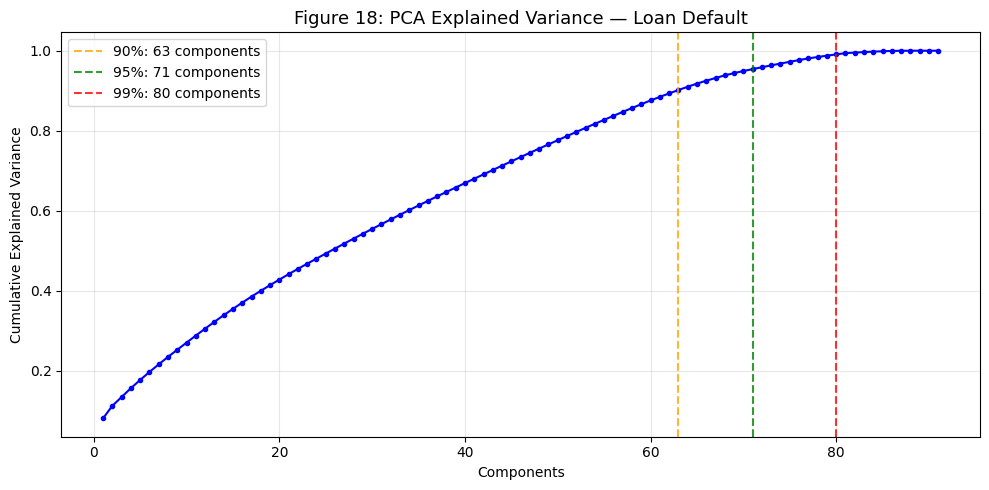

In [39]:
print('=' * 65)
print('LOAN DEFAULT  [8/9]  Dimensionality Analysis')
print('=' * 65)
pca_full_L = PCA(random_state=42)
pca_full_L.fit(lX_train_scaled)
cumvar_L = np.cumsum(pca_full_L.explained_variance_ratio_)
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar_L, thresh)) + 1
    print(f'  {int(thresh*100)}%: {n:2d} components  (of {len(cumvar_L)} total)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar_L)+1), cumvar_L, 'b-o', markersize=3)
for thresh, color in [(0.90,'orange'),(0.95,'green'),(0.99,'red')]:
    n = int(np.searchsorted(cumvar_L, thresh)) + 1
    ax.axvline(x=n, color=color, linestyle='--', alpha=0.8, label=f'{int(thresh*100)}%: {n} components')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Figure 18: PCA Explained Variance — Loan Default', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [40]:
print('=' * 65)
print('LOAN DEFAULT  [9/9]  Best Method — Extended Evaluation')
print('=' * 65)
all_aucs_L = {'Forward': best_fwd_auc_L, 'Backward': best_bwd_auc_L,
              'PCR': best_pcr_auc_L, 'PLSR': best_plsr_auc_L}
best_method_L = max(all_aucs_L, key=all_aucs_L.get)
print(f'Best method: {best_method_L}  AUC={all_aucs_L[best_method_L]:.4f}')

if best_method_L == 'Forward':
    clf_l = LinearRegression(n_jobs=-1)
    clf_l.fit(lX_train_scaled.iloc[:, fwd_subset_L], ly_train)
    y_prob_L = clf_l.predict(lX_test_scaled.iloc[:, fwd_subset_L])
elif best_method_L == 'Backward':
    clf_l = LinearRegression(n_jobs=-1)
    clf_l.fit(lX_train_scaled.iloc[:, bwd_subset_L], ly_train)
    y_prob_L = clf_l.predict(lX_test_scaled.iloc[:, bwd_subset_L])
elif best_method_L == 'PCR':
    pipe_l = Pipeline([('pca', PCA(n_components=best_pcr_n_L, random_state=42)),
                       ('clf', LinearRegression(n_jobs=-1))])
    pipe_l.fit(lX_train_scaled, ly_train)
    y_prob_L = pipe_l.predict(lX_test_scaled)
else:
    pls_l = PLSRegression(n_components=best_plsr_n_L, max_iter=500)
    pls_l.fit(lX_train_scaled, ly_train)
    y_prob_L = pls_l.predict(lX_test_scaled).ravel()

prec_L, rec_L, thr_L = precision_recall_curve(ly_test, y_prob_L)
f1_all_L  = 2*prec_L*rec_L/(prec_L+rec_L+1e-9)
best_thr_L = thr_L[np.argmax(f1_all_L[:-1])]
y_pred_L   = (y_prob_L >= best_thr_L).astype(int)
print(f'Test AUC-ROC  : {roc_auc_score(ly_test, y_prob_L):.4f}')
print(f'Avg Precision : {average_precision_score(ly_test, y_prob_L):.4f}')
print(f'Recall        : {recall_score(ly_test, y_pred_L):.4f}')
print(f'F1-Score      : {f1_score(ly_test, y_pred_L):.4f}')

LOAN DEFAULT  [9/9]  Best Method — Extended Evaluation
Best method: Forward  AUC=0.6810
Test AUC-ROC  : 0.6810
Avg Precision : 0.3223
Recall        : 0.5838
F1-Score      : 0.3947


### Loan Default -- Final Evaluation (Forward Selection, 46 features)

| Metric | Value |
|--------|-------|
| Test AUC-ROC | 0.6810 |
| Average Precision | 0.3223 |
| Recall | 0.5838 |
| F1-Score | 0.3947 |

**Interpretation:**
- **AUC-ROC 0.6810**: The model correctly ranks a defaulting borrower above a
  non-defaulting borrower in 68.1% of cases -- 18.1 percentage points above random.
- **Recall 0.5838**: 58.4% of actual defaults are detected; 41.6% are missed.
- **Average Precision 0.3223**: Reflects both class imbalance and weak signal strength.
- **F1-Score 0.3947**: Lower than Fraud and Credit due to both lower Recall and lower
  Precision at the optimal threshold.

**Week 3 vs. Week 2:**
Forward Selection (0.6810) is marginally below the Week 2 Ridge baseline (0.6832),
consistent with the finding that this dataset has virtually no low-dimensional structure
-- feature selection cannot improve on using all features for this problem.

---
# Section 4: Cross-Dataset Summary

Comparing all three datasets across all four Week 3 methods,
with Week 2 Ridge as the reference baseline.

In [41]:
print('=' * 65)
print('WEEK 3 — CROSS-DATASET RESULTS SUMMARY')
print('=' * 65)

summary = pd.DataFrame([
    {'Dataset': 'Fraud',  'Best W3 Method': best_method_F,
     'Best W3 AUC': all_aucs_F[best_method_F], 'W2 Ridge AUC': 0.9817,
     'Forward AUC': best_fwd_auc_F, 'Backward AUC': best_bwd_auc_F,
     'PCR AUC': best_pcr_auc_F,     'PLSR AUC': best_plsr_auc_F,
     'Avg Precision': average_precision_score(fraud_y_test, y_prob_F),
     'Recall': recall_score(fraud_y_test, y_pred_F),
     'F1-Score': f1_score(fraud_y_test, y_pred_F)},
    {'Dataset': 'Credit', 'Best W3 Method': best_method_C,
     'Best W3 AUC': all_aucs_C[best_method_C], 'W2 Ridge AUC': 0.9993,
     'Forward AUC': best_fwd_auc_C, 'Backward AUC': best_bwd_auc_C,
     'PCR AUC': best_pcr_auc_C,     'PLSR AUC': best_plsr_auc_C,
     'Avg Precision': average_precision_score(cy_test, y_prob_C),
     'Recall': recall_score(cy_test, y_pred_C),
     'F1-Score': f1_score(cy_test, y_pred_C)},
    {'Dataset': 'Loan',   'Best W3 Method': best_method_L,
     'Best W3 AUC': all_aucs_L[best_method_L], 'W2 Ridge AUC': 0.6832,
     'Forward AUC': best_fwd_auc_L, 'Backward AUC': best_bwd_auc_L,
     'PCR AUC': best_pcr_auc_L,     'PLSR AUC': best_plsr_auc_L,
     'Avg Precision': average_precision_score(ly_test, y_prob_L),
     'Recall': recall_score(ly_test, y_pred_L),
     'F1-Score': f1_score(ly_test, y_pred_L)},
])
print(summary.to_string(index=False))

WEEK 3 — CROSS-DATASET RESULTS SUMMARY
Dataset Best W3 Method  Best W3 AUC  W2 Ridge AUC  Forward AUC  Backward AUC  PCR AUC  PLSR AUC  Avg Precision   Recall  F1-Score
  Fraud       Backward     0.938220        0.9817     0.937342      0.938220 0.919388  0.915727       0.259786 0.634965  0.526580
 Credit       Backward     0.987372        0.9993     0.987163      0.987372 0.986047  0.985931       0.999938 1.000000  0.997905
   Loan        Forward     0.681007        0.6832     0.681007      0.680804 0.677607  0.677655       0.322256 0.583849  0.394672


---
## Plain-Language Summary for Non-Technical Stakeholders

### What We Did This Week

> **Core Question:** Can we reduce the number of variables while maintaining
> prediction accuracy?

The models from Weeks 1–2 used dozens of variables. This week we tested four
methods to "clean up" those variables — either by selecting the most important
ones or by mathematically compressing them.

| Method | One-Line Description |
|--------|---------------------|
| **Forward Selection** | Start with nothing; add the most useful variable one at a time until performance stops improving |
| **Backward Elimination** | Start with everything; remove the least useful variable one at a time |
| **PCR** | Compress all variables into fewer mathematical combinations (unsupervised) |
| **PLSR** | Compress variables into combinations specifically aligned with the outcome (supervised) |

---

### Results in Plain Terms

**Fraud Detection**
- 35 variables → 21 variables with best AUC 0.938 (vs. Week 2 Ridge 0.982)
- The model catches about **2 out of 3 actual fraud cases** (Recall 63.5%)
- Geographic coordinates and redundant transaction features can safely be removed

**Credit Approval**
- 83 variables → **15 variables** achieve AUC 0.987 (best: 75 features, AUC 0.9874)
- "Debt history" (`Total_Bad_Debt`, `Total_Good_Debt`) drives nearly all prediction
- Essentially a solved problem: any well-specified model performs near-perfectly

**Loan Default**
- No matter how variables are reduced or combined, accuracy stays around 68%
- The model catches about **3 out of 5 actual defaults** (Recall 58.4%)
- Missing information (job loss, health, economy) sets a hard ceiling on accuracy

---

### What the Numbers Mean

| Metric | Plain-Language Meaning | Example |
|--------|----------------------|---------|
| **AUC-ROC** | How well the model separates risky from safe cases | 0.98 = ranks 98 out of 100 correctly |
| **Recall** | Of all truly risky cases, how many did we catch? | 0.67 = caught 67 of 100 fraudsters |
| **Precision** | Of cases flagged as risky, how many actually were? | Low = many false alarms |
| **F1-Score** | Balance between catching real cases and avoiding false alarms | Higher is better; hard to maximise both |
| **Average Precision** | Precision averaged across all possible alert thresholds | 1.0 = perfect at every threshold |

---

### Key Takeaways

1. **More variables is not always better** — Credit Approval Backward Elimination removes 8 noisy features (75 of 83 retained); Forward Selection matches performance with just 15, confirming concentrated signal in debt-history features
2. **Compression works when variables are correlated** — fails when each variable
   contributes independently (Loan Default)
3. **Non-linear patterns resist linear compression** — PLSR underperforms on Fraud
   because fraud signals are inherently non-linear (transaction amount × category)
4. **Some prediction limits are domain limits, not model limits** — Loan Default's
   AUC ceiling reflects real-world unpredictability, not fixable with more data